# Concrete Compressive Strength - Predicción de Resistencia
## Proyecto CRISP-DM: Selección de Características, PCA y Despliegue en Render

* **URL del dataset:** https://raw.githubusercontent.com/MarcosUriel123/datasets/main/concrete_data.csv
* **URL pública de Render:** https://concrete-strength-render.onrender.com

## Descripción de columnas del dataset

- **cement**: cemento (kg/m³).
- **blast_furnace_slag**: escoria de alto horno (kg/m³).
- **fly_ash**: ceniza volante (kg/m³).
- **water**: agua (kg/m³).
- **superplasticizer**: superplastificante (kg/m³).
- **coarse_aggregate**: agregado grueso (kg/m³).
- **fine_aggregate**: agregado fino (kg/m³).
- **age**: edad de curado (días).
- **concrete_compressive_strength**: resistencia a la compresión (MPa) — variable objetivo.

## CRISP-DM 1 - Comprensión del negocio

El dataset describe 1,030 mezclas de concreto de laboratorio (Yeh, 1998), cada una con sus 8 componentes y la resistencia medida tras el curado. El problema real: la resistencia solo se conoce días después de fabricar la mezcla (ensayo destructivo), por lo que predecirla antes ahorra tiempo y costo.

**Quién lo usaría:** ingenieros civiles y laboratorios de control de calidad de concreto premezclado.

**Decisiones que apoya:** ajustar la dosificación (cemento, agua, aditivos) antes de fabricar la mezcla, o decidir si una mezcla es apta para cierto elemento estructural (cimentación, columna, losa).

**Beneficios:** menos ensayos físicos redundantes, optimización de costos de materiales (el cemento es el componente más costoso), y detección temprana de mezclas de baja resistencia.

**Consecuencias de una predicción incorrecta:**
- *Sobreestimación* (el modelo predice más resistencia de la real): riesgo de usar una mezcla insuficiente en una estructura, comprometiendo la seguridad de la construcción.
- *Subestimación* (el modelo predice menos resistencia de la real): sobrecosto innecesario por usar más cemento del necesario.

**Riesgos en un entorno real:** el modelo nunca debe sustituir el ensayo físico normativo exigido por reglamentos de construcción; usarlo como única fuente de verificación estructural, sin validación física, representa un riesgo directo de seguridad estructural, especialmente en mezclas de resistencia muy alta o muy baja, donde el modelo tiene mayor margen de error (ver análisis de residuos, sección 3.7).

## CRISP-DM 2 - Comprensión de los datos / Paso 1 - Carga de datos

Se carga el dataset desde GitHub para revisar su tamaño y tipos de datos antes de cualquier transformación.

Se importan las librerías y se carga el dataset desde la URL remota.

In [2]:
import pandas as pd
import numpy as np
from IPython.display import display

SEED = 42
np.random.seed(SEED)

url = "https://raw.githubusercontent.com/MarcosUriel123/datasets/main/concrete_data.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
df.head()

Shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


Todas las columnas son `float64` o `int64`; no hay tipos incorrectos.

In [3]:
df.dtypes

cement                           float64
blast_furnace_slag               float64
fly_ash                          float64
water                            float64
superplasticizer                 float64
coarse_aggregate                 float64
fine_aggregate                   float64
age                                int64
concrete_compressive_strength    float64
dtype: object

Porcentaje de nulos por columna (calculado dinámicamente abajo) en el dataset original.

In [4]:
df.isnull().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

Tabla de atributos: tipo de variable (nominal/ordinal/discreto/continuo), tipo de dato en Python, nulos y % de nulos.

In [5]:
descripciones_attr = {
    "cement": "Cantidad de cemento Portland en la mezcla (kg/m³)",
    "blast_furnace_slag": "Cantidad de escoria de alto horno, material cementante secundario (kg/m³)",
    "fly_ash": "Cantidad de ceniza volante, material cementante secundario (kg/m³)",
    "water": "Cantidad de agua utilizada en la mezcla (kg/m³)",
    "superplasticizer": "Cantidad de superplastificante, aditivo que mejora la trabajabilidad (kg/m³)",
    "coarse_aggregate": "Cantidad de agregado grueso (grava) en la mezcla (kg/m³)",
    "fine_aggregate": "Cantidad de agregado fino (arena) en la mezcla (kg/m³)",
    "age": "Edad del concreto al momento del ensayo de resistencia (días)",
    "concrete_compressive_strength": "Resistencia a la compresión medida en laboratorio (MPa) - variable dependiente"
}
tipos_attr = {
    "cement": "Continuo", "blast_furnace_slag": "Continuo", "fly_ash": "Continuo",
    "water": "Continuo", "superplasticizer": "Continuo", "coarse_aggregate": "Continuo",
    "fine_aggregate": "Continuo", "age": "Discreto", "concrete_compressive_strength": "Continuo"
}

tabla_atributos = pd.DataFrame({
    "Atributo": df.columns,
    "Descripción": [descripciones_attr[c] for c in df.columns],
    "Tipo de atributo": [tipos_attr[c] for c in df.columns],
    "Tipo de dato en Python": [str(df[c].dtype) for c in df.columns],
    "Nulos": df.isnull().sum().values,
    "% de nulos": (df.isnull().sum().values / len(df) * 100).round(2)
})
display(tabla_atributos)

,Atributo,Descripción,Tipo de atributo,Tipo de dato en Python,Nulos,% de nulos
0,cement,Cantidad de cemento Portland en la mezcla (kg/m³),Continuo,float64,0,0.0
1,blast_furnace_slag,"Cantidad de escoria de alto horno, material ce...",Continuo,float64,0,0.0
2,fly_ash,"Cantidad de ceniza volante, material cementant...",Continuo,float64,0,0.0
3,water,Cantidad de agua utilizada en la mezcla (kg/m³),Continuo,float64,0,0.0
4,superplasticizer,"Cantidad de superplastificante, aditivo que me...",Continuo,float64,0,0.0
5,coarse_aggregate,Cantidad de agregado grueso (grava) en la mezc...,Continuo,float64,0,0.0
6,fine_aggregate,Cantidad de agregado fino (arena) en la mezcla...,Continuo,float64,0,0.0
7,age,Edad del concreto al momento del ensayo de res...,Discreto,int64,0,0.0
8,concrete_compressive_strength,Resistencia a la compresión medida en laborato...,Continuo,float64,0,0.0


## Paso 2 - Calidad de datos: duplicados

Se detectan y eliminan filas idénticas para evitar que una misma observación influya dos veces en el entrenamiento o la evaluación.

Porcentaje de duplicados exactos eliminados (calculado dinámicamente arriba) sobre el total original.

In [6]:
total_original = len(df)
duplicados_exactos = df.duplicated().sum()
print(f"Duplicados exactos: {duplicados_exactos} ({duplicados_exactos/total_original*100:.2f}% del total)")

df = df.drop_duplicates().reset_index(drop=True)
print("Shape tras eliminar duplicados:", df.shape)

Duplicados exactos: 25 (2.43% del total)
Shape tras eliminar duplicados: (1005, 9)


13 filas con la misma mezcla (X) pero distinto resultado de resistencia: variabilidad real de laboratorio, se conservan.

In [7]:
target_col = "concrete_compressive_strength"
X_cols = [c for c in df.columns if c != target_col]

duplicados_parciales = df.duplicated(subset=X_cols).sum()
print("Duplicados parciales (misma X, distinto target):", duplicados_parciales)

Duplicados parciales (misma X, distinto target): 13


Detección de valores atípicos mediante rango intercuartílico (IQR) en cada variable. Detección de valores atípicos (outliers) mediante el método IQR: se considera atípico cualquier valor que se aleje más de 1.5 veces el rango intercuartílico (la "zona central" donde está el 50% de los datos) por encima o por debajo de lo normal — es el mismo criterio que define los bigotes de un boxplot.

In [8]:
outliers_resumen = {}
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    outliers_resumen[col] = n_outliers

outliers_df = pd.DataFrame(list(outliers_resumen.items()), columns=["Variable", "N° de outliers (IQR x1.5)"])
outliers_df["% del total"] = (outliers_df["N° de outliers (IQR x1.5)"] / len(df) * 100).round(2)
display(outliers_df)

,Variable,N° de outliers (IQR x1.5),% del total
0,cement,0,0.00
1,blast_furnace_slag,2,0.20
2,fly_ash,0,0.00
3,water,15,1.49
4,superplasticizer,10,1.00
5,coarse_aggregate,0,0.00
6,fine_aggregate,5,0.50
7,age,59,5.87
8,concrete_compressive_strength,8,0.80


Los atípicos se concentran en `superplasticizer`, `fly_ash` y `age`, consistente con su uso parcial (muchos ceros) y no se eliminan, ya que corresponden a mezclas y edades de ensayo válidas, no a errores de medición.

Verificación de columnas constantes o con varianza muy baja, y de columnas identificadoras sin utilidad predictiva.

In [9]:
print("Varianza de cada columna:")
print(df.var().round(2))
print()
print("Número de valores únicos por columna:")
print(df.nunique())

Varianza de cada columna:
cement                           10887.72
blast_furnace_slag                7425.41
fly_ash                           4122.66
water                              455.37
superplasticizer                    35.05
coarse_aggregate                  6018.60
fine_aggregate                    6454.59
age                               4062.11
concrete_compressive_strength      265.20
dtype: float64

Número de valores únicos por columna:
cement                           278
blast_furnace_slag               185
fly_ash                          156
water                            195
superplasticizer                 111
coarse_aggregate                 284
fine_aggregate                   302
age                               14
concrete_compressive_strength    845
dtype: int64


Ninguna columna es constante ni tiene varianza nula; todas muestran suficientes valores únicos para aportar información. El dataset no contiene columnas de tipo identificador, folio o índice.

## Paso 3 - Análisis exploratorio (EDA)

Se revisan estadísticas y gráficas para identificar distribuciones, relaciones y posibles atípicos antes de modelar.

Se importan las librerías de visualización.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1005.0,278.631343,104.344261,102.00,190.70,265.0,349.00,540.0
blast_furnace_slag,1005.0,72.043483,86.170807,0.00,0.00,20.0,142.50,359.4
fly_ash,1005.0,55.536318,64.207969,0.00,0.00,0.0,118.30,200.1
water,1005.0,182.075323,21.339334,121.80,166.60,185.7,192.90,247.0
superplasticizer,1005.0,6.033234,5.919967,0.00,0.00,6.1,10.00,32.2
coarse_aggregate,1005.0,974.376816,77.579667,801.00,932.00,968.0,1031.00,1145.0
fine_aggregate,1005.0,772.688259,80.340435,594.00,724.30,780.0,822.20,992.6
age,1005.0,45.856716,63.734692,1.00,7.00,28.0,56.00,365.0
concrete_compressive_strength,1005.0,35.250378,16.284815,2.33,23.52,33.8,44.87,82.6


Estadísticas descriptivas de la variable objetivo (calculadas dinámicamente en la celda siguiente).

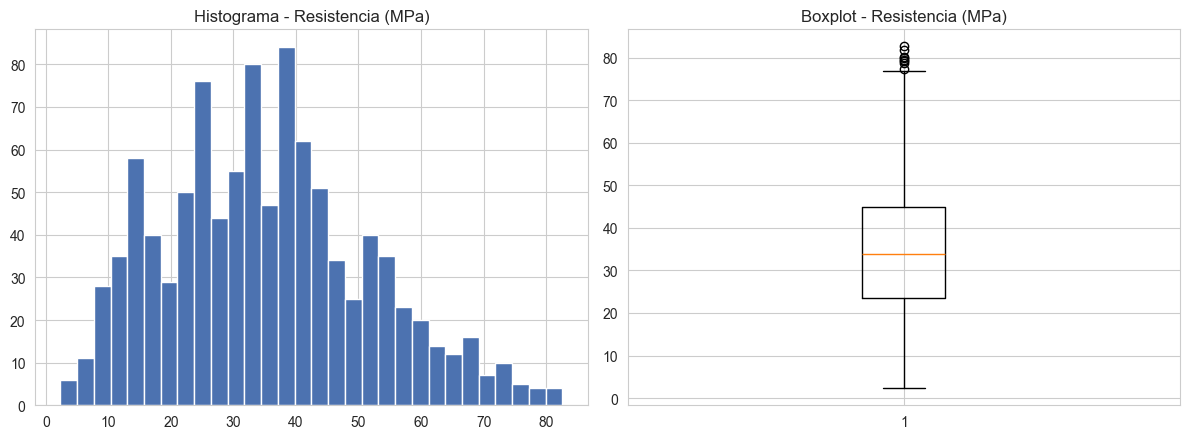

Media: 35.25 MPa | Mínimo: 2.33 | Máximo: 82.60 | Asimetría: 0.40


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df[target_col], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Histograma - Resistencia (MPa)")
axes[1].boxplot(df[target_col])
axes[1].set_title("Boxplot - Resistencia (MPa)")
plt.tight_layout()
plt.show()

print(f"Media: {df[target_col].mean():.2f} MPa | Mínimo: {df[target_col].min():.2f} | Máximo: {df[target_col].max():.2f} | Asimetría: {df[target_col].skew():.2f}")

`age`, `fly_ash` y `superplasticizer` muestran fuerte sesgo a la derecha (muchas mezclas con valor 0) por su uso parcial; esto genera valores atípicos visibles en los boxplots de estas tres variables. Consecuencia para el modelado: un modelo lineal (Ridge) puede subestimar su efecto; un modelo de árboles (Random Forest) maneja mejor estas distribuciones sesgadas sin verse afectado por los atípicos.

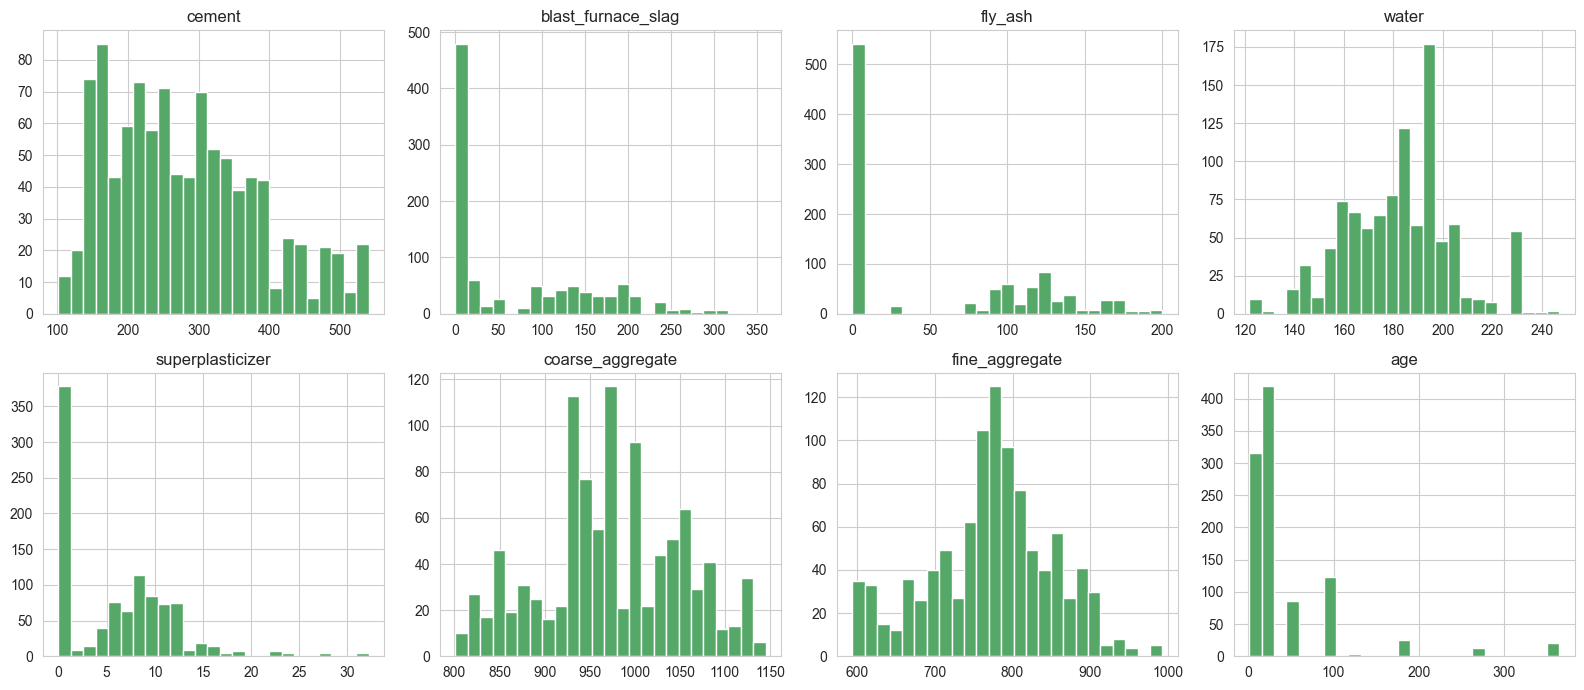

Asimetría (skew): age=3.25, fly_ash=0.50, superplasticizer=0.98


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(X_cols):
    axes[i].hist(df[col], bins=25, color="#55A868", edgecolor="white")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

print(f"Asimetría (skew): age={df['age'].skew():.2f}, fly_ash={df['fly_ash'].skew():.2f}, superplasticizer={df['superplasticizer'].skew():.2f}")

Las correlaciones más fuertes (positivas y negativas) con la resistencia se cuantifican con precisión sobre el conjunto de entrenamiento en el Paso 8. Aquí se observa relación lineal moderada de `cement` y `age` con la resistencia, y relación inversa de `water`; el resto de variables muestra relación lineal débil, lo que sugiere que un modelo puramente lineal podría no ser suficiente.

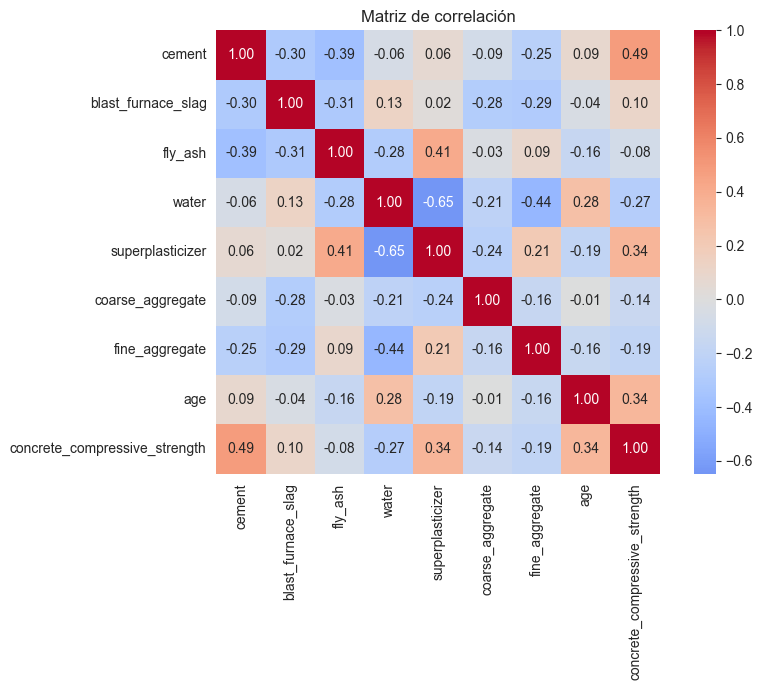

In [13]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

`age` muestra relación no lineal (curva, no recta) con la resistencia: crece rápido en los primeros días y luego se estabiliza. Esto es clave para el modelado: justifica incluir un algoritmo no lineal (MLPRegressor o Random Forest), ya que un modelo lineal (Ridge) no podría capturar esta curva.

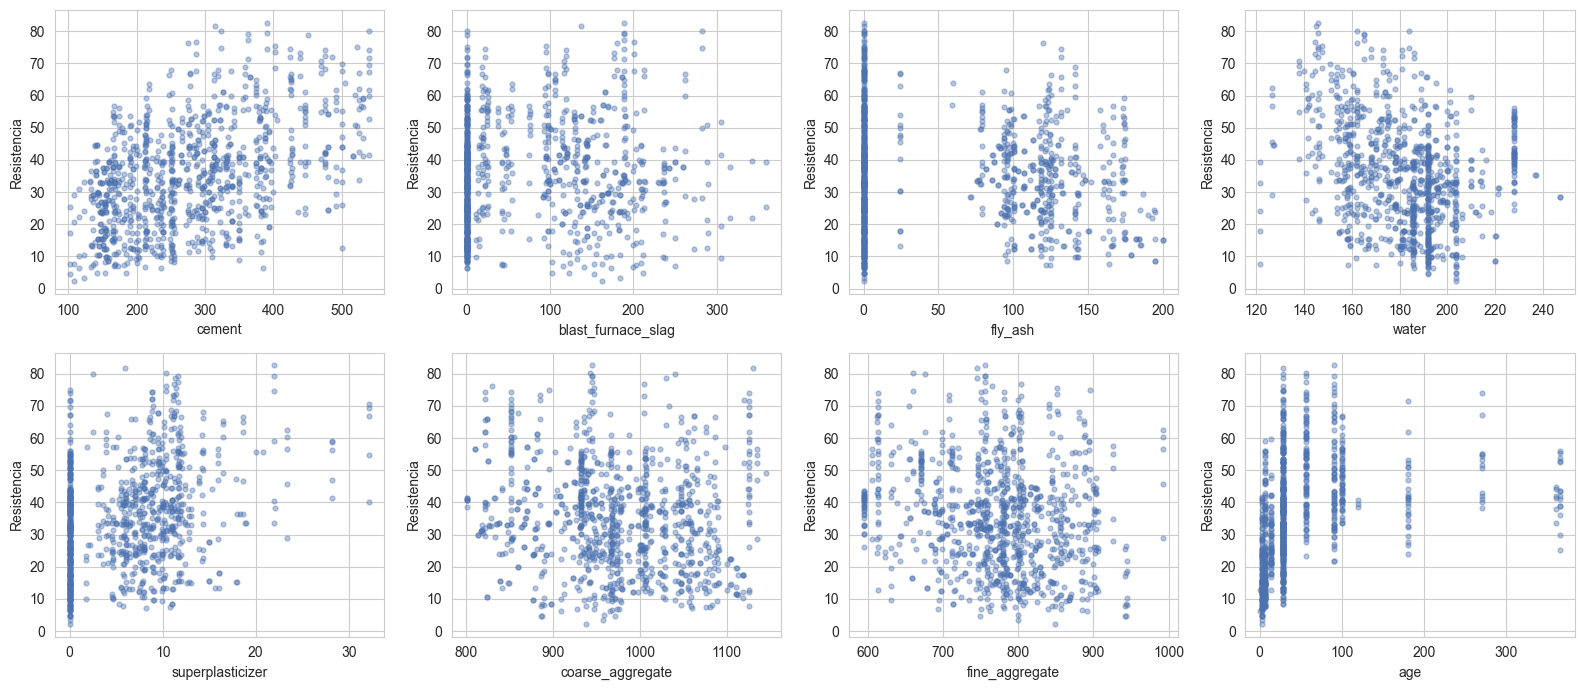

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(X_cols):
    axes[i].scatter(df[col], df[target_col], alpha=0.4, s=12, color="#4C72B0")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Resistencia")
plt.tight_layout()
plt.show()

## CRISP-DM 3 - Preparación de datos / Paso 4 - Definición de X y y

Se separan las variables predictoras (X) de la variable a predecir (y), base de cualquier modelo de regresión. Las 8 variables independientes son numéricas; el dataset **no contiene variables categóricas**, por lo que no se requiere codificación (OneHotEncoder/OrdinalEncoder).

Se definen X (predictoras) y y (variable objetivo). y es numérica continua (MPa, no categorías), por lo que el problema es de regresión, no clasificación.

In [15]:
X = df[X_cols].copy()
y = df[target_col].copy()
print("X:", X.shape, "| y:", y.shape)

X: (1005, 8) | y: (1005,)


## Paso 5 - Generación artificial de nulos (semilla fija, solo en X)

Como el dataset no tenía nulos, se generan de forma controlada para luego practicar y justificar una técnica de imputación.

Se generan nulos artificiales con semilla fija, solo en columnas de X.

In [16]:
rng = np.random.RandomState(SEED)
columnas_con_nulos = ["cement", "water", "age"]
porcentaje_nulos = 0.05

for col in columnas_con_nulos:
    n_nulos = int(len(X) * porcentaje_nulos)
    idx = rng.choice(X.index, size=n_nulos, replace=False)
    X.loc[idx, col] = np.nan

X.isnull().sum()

cement                50
blast_furnace_slag     0
fly_ash                0
water                 50
superplasticizer       0
coarse_aggregate       0
fine_aggregate         0
age                   50
dtype: int64

## Paso 6 - División train/test (80/20)

Se aparta un 20% de los datos que no se usará hasta la evaluación final, para medir el desempeño con datos nunca vistos por el modelo.

Se divide el dataset en 80% entrenamiento y 20% prueba.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (804, 8) | X_test: (201, 8)


## CRISP-DM 4 - Selección de características / Paso 7 - Imputación y escalado (entrenamiento)

Se imputan los nulos y se escalan las variables solo con datos de entrenamiento, para evitar fuga de información hacia el proceso de selección.

Se imputan los nulos (mediana, por la asimetría de `age`) y se escala X_train con StandardScaler. Se descarta MinMaxScaler porque comprime los atípicos legítimos de `superplasticizer`/`fly_ash` al rango [0,1] sin centrarlos; se descarta RobustScaler porque esos 'atípicos' no son errores sino mezclas sin aditivo (válidas). StandardScaler es indispensable para que MLPRegressor converja y para que PCA no esté dominado por variables de mayor magnitud (ej. coarse_aggregate); RandomForest no lo necesita, pero se aplica igual para mantener condiciones equivalentes entre los 3 modelos.

In [18]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer_temp = SimpleImputer(strategy="median")
scaler_temp = StandardScaler()

X_train_imputado = pd.DataFrame(imputer_temp.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_train_escalado = pd.DataFrame(scaler_temp.fit_transform(X_train_imputado), columns=X_train.columns, index=X_train.index)

print("Nulos restantes tras imputación:", X_train_imputado.isnull().sum().sum())

X_train_escalado.describe().round(2).T[["mean", "std"]]

Nulos restantes tras imputación: 0


,mean,std
cement,-0.0,1.0
blast_furnace_slag,-0.0,1.0
fly_ash,0.0,1.0
water,0.0,1.0
superplasticizer,0.0,1.0
coarse_aggregate,-0.0,1.0
fine_aggregate,-0.0,1.0
age,0.0,1.0


## Paso 8 - Matriz de correlación (sobre entrenamiento)

Mide la relación lineal entre todas las variables y con la resistencia; sirve como primer filtro, no detecta relaciones no lineales ni multicolinealidad por sí sola sin revisar la matriz completa.

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
cement,1.000,-0.290,-0.399,-0.034,0.057,-0.094,-0.241,0.108,0.497
blast_furnace_slag,-0.290,1.000,-0.319,0.120,0.014,-0.279,-0.298,-0.027,0.111
fly_ash,-0.399,-0.319,1.000,-0.286,0.414,-0.019,0.109,-0.152,-0.088
water,-0.034,0.120,-0.286,1.000,-0.630,-0.197,-0.447,0.258,-0.249
superplasticizer,0.057,0.014,0.414,-0.630,1.000,-0.263,0.234,-0.175,0.353
coarse_aggregate,-0.094,-0.279,-0.019,-0.197,-0.263,1.000,-0.163,-0.026,-0.173
fine_aggregate,-0.241,-0.298,0.109,-0.447,0.234,-0.163,1.000,-0.197,-0.179
age,0.108,-0.027,-0.152,0.258,-0.175,-0.026,-0.197,1.000,0.346
concrete_compressive_strength,0.497,0.111,-0.088,-0.249,0.353,-0.173,-0.179,0.346,1.000


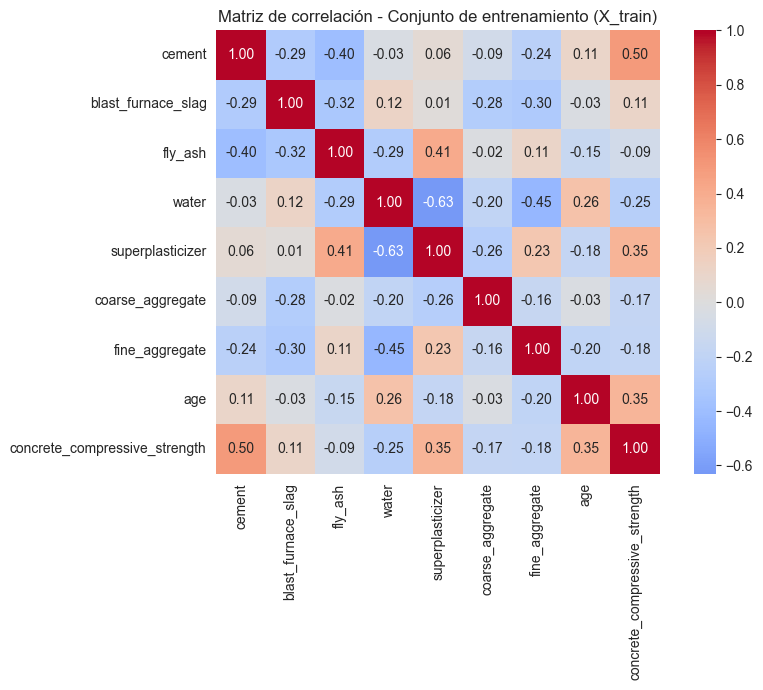

Par de variables independientes más correlacionado entre sí: ('water', 'superplasticizer') (r=-0.630)


In [19]:
train_con_target = X_train_escalado.copy()
train_con_target[target_col] = y_train.values

corr_train = train_con_target.corr()[target_col].drop(target_col).sort_values(key=abs, ascending=False)
corr_train

matriz_corr_train = train_con_target.corr()
display(matriz_corr_train.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr_train, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación - Conjunto de entrenamiento (X_train)")
plt.tight_layout()
plt.show()

corr_independientes = matriz_corr_train.drop(columns=[target_col]).drop(index=target_col)
corr_independientes_sin_diag = corr_independientes.where(~np.eye(len(corr_independientes), dtype=bool))
par_mas_correlacionado = corr_independientes_sin_diag.abs().stack().idxmax()
valor_mas_correlacionado = corr_independientes_sin_diag.loc[par_mas_correlacionado]

print(f"Par de variables independientes más correlacionado entre sí: {par_mas_correlacionado} (r={valor_mas_correlacionado:.3f})")

## Paso 9 - RFE (Recursive Feature Elimination)

Elimina iterativamente la variable menos relevante para un modelo lineal, hasta quedarse con las 5 más influyentes en conjunto (no de forma aislada).

RFE usa LinearRegression porque expone coeficientes para rankear variables; la columna 'Ranking RFE' de la tabla siguiente muestra qué variables descarta y por qué (colinealidad con otras conservadas).

In [20]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

rfe = RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(X_train_escalado, y_train)

ranking_rfe = pd.DataFrame({
    "Variable": X_train_escalado.columns,
    "Seleccionada (RFE)": rfe.support_,
    "Ranking RFE": rfe.ranking_
}).sort_values("Ranking RFE")
ranking_rfe

,Variable,Seleccionada (RFE),Ranking RFE
0,cement,True,1
1,blast_furnace_slag,True,1
2,fly_ash,True,1
7,age,True,1
6,fine_aggregate,True,1
5,coarse_aggregate,False,2
4,superplasticizer,False,3
3,water,False,4


## Paso 10 - Importancia por árboles (Random Forest)

Mide cuánto reduce el error cada variable al construir los árboles; a diferencia de la correlación, sí detecta relaciones no lineales.

La tabla de importancia (abajo) y su gráfica muestran qué variables concentra mayor peso el Random Forest, contrastando con los resultados de correlación y RFE.

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_importancia = RandomForestRegressor(n_estimators=100, random_state=SEED)
rf_importancia.fit(X_train_escalado, y_train)

importancia_df = pd.DataFrame({
    "Variable": X_train_escalado.columns,
    "Importancia": rf_importancia.feature_importances_
}).sort_values("Importancia", ascending=False).reset_index(drop=True)
importancia_df

,Variable,Importancia
0,age,0.334920
1,cement,0.316594
2,water,0.090741
3,superplasticizer,0.085502
4,blast_furnace_slag,0.073997
5,fine_aggregate,0.046493
6,coarse_aggregate,0.031780
7,fly_ash,0.019973


Se grafica la importancia obtenida.

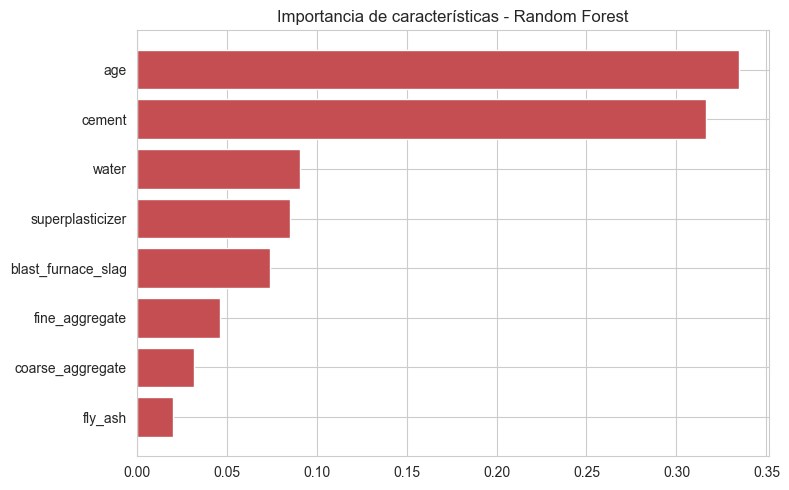

In [22]:
plt.figure(figsize=(8, 5))
plt.barh(importancia_df["Variable"], importancia_df["Importancia"], color="#C44E52")
plt.gca().invert_yaxis()
plt.title("Importancia de características - Random Forest")
plt.tight_layout()
plt.show()

## Paso 11 - Tabla comparativa y selección final

Se integran los tres métodos y se conservan las 5 variables con mayor consenso, priorizando Random Forest por capturar relaciones no lineales.

Se eligen `age`, `cement`, `superplasticizer`, `water` y `blast_furnace_slag`: las 5 con mayor importancia en Random Forest. `fine_aggregate` fue seleccionada por RFE, pero se excluyó porque, entre las variables con al menos una señal a favor (correlación, RFE o importancia), es la que tiene la importancia más baja (valor exacto en la tabla siguiente); se priorizó Random Forest por capturar la no linealidad de `age`.

In [23]:
tabla_seleccion = pd.DataFrame({
    "Característica": X_train_escalado.columns,
    "Correlación (|r|)": [round(abs(corr_train[c]), 3) for c in X_train_escalado.columns],
    "RFE (seleccionada)": [bool(ranking_rfe.set_index("Variable").loc[c, "Seleccionada (RFE)"]) for c in X_train_escalado.columns],
    "Importancia RF": [round(importancia_df.set_index("Variable").loc[c, "Importancia"], 3) for c in X_train_escalado.columns],
}).sort_values("Importancia RF", ascending=False).reset_index(drop=True)

caracteristicas_seleccionadas = ["age", "cement", "superplasticizer", "water", "blast_furnace_slag"]
tabla_seleccion["Decisión"] = tabla_seleccion["Característica"].apply(
    lambda c: "Incluir" if c in caracteristicas_seleccionadas else "Excluir"
)

print("Características seleccionadas (Escenario 1):", caracteristicas_seleccionadas)
tabla_seleccion

Características seleccionadas (Escenario 1): ['age', 'cement', 'superplasticizer', 'water', 'blast_furnace_slag']


,Característica,Correlación (|r|),RFE (seleccionada),Importancia RF,Decisión
0,age,0.346,True,0.335,Incluir
1,cement,0.497,True,0.317,Incluir
2,water,0.249,False,0.091,Incluir
3,superplasticizer,0.353,False,0.086,Incluir
4,blast_furnace_slag,0.111,True,0.074,Incluir
5,fine_aggregate,0.179,True,0.046,Excluir
6,coarse_aggregate,0.173,False,0.032,Excluir
7,fly_ash,0.088,True,0.020,Excluir


## Paso 12 - PCA (Escenario 2)

Combina las 8 variables originales en componentes no correlacionados entre sí, eliminando la colinealidad detectada en la correlación.

Se calcula la varianza explicada por cada componente principal.

In [24]:
from sklearn.decomposition import PCA

pca_completo = PCA(n_components=8, random_state=SEED)
pca_completo.fit(X_train_escalado)

varianza_explicada = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

tabla_pca = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(8)],
    "Varianza explicada (%)": (varianza_explicada * 100).round(2),
    "Varianza acumulada (%)": (varianza_acumulada * 100).round(2)
})
tabla_pca

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,29.11,29.11
1,PC2,17.64,46.75
2,PC3,16.15,62.89
3,PC4,12.57,75.46
4,PC5,11.85,87.31
5,PC6,9.76,97.07
6,PC7,2.43,99.51
7,PC8,0.49,100.00


La varianza explicada por cada componente (tabla y gráfica siguientes) indica si existe o no un componente dominante.

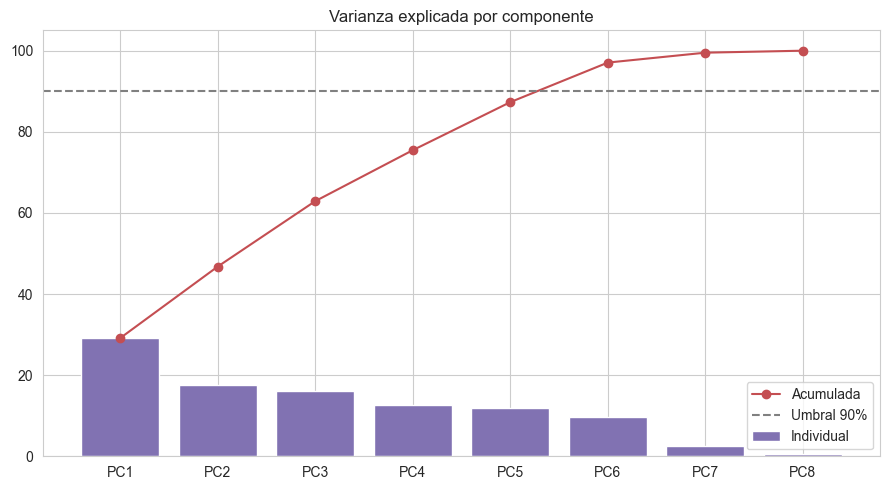

In [25]:
plt.figure(figsize=(9, 5))
plt.bar(tabla_pca["Componente"], tabla_pca["Varianza explicada (%)"], color="#8172B2", label="Individual")
plt.plot(tabla_pca["Componente"], tabla_pca["Varianza acumulada (%)"], color="#C44E52", marker="o", label="Acumulada")
plt.axhline(90, color="gray", linestyle="--", label="Umbral 90%")
plt.legend()
plt.title("Varianza explicada por componente")
plt.tight_layout()
plt.show()

El número de componentes conservados (impreso abajo) es el mínimo necesario para superar el umbral de 90% de varianza acumulada.

In [26]:
N_COMPONENTES_PCA = 6
print(f"Varianza acumulada con {N_COMPONENTES_PCA} componentes: {varianza_acumulada[N_COMPONENTES_PCA-1]*100:.2f}%")

Varianza acumulada con 6 componentes: 97.07%


## CRISP-DM 5 - Modelado / Paso 13 - Construcción de pipelines (ambos escenarios)

Se encapsulan todos los pasos de preprocesamiento y el modelo en un solo objeto, para aplicar exactamente las mismas transformaciones en cada partición.

Se construyen los pipelines de los dos escenarios. Los 3 algoritmos usan parámetros fijos razonables (no ajustados contra el test, evitando fuga); no se realizó una búsqueda ni un ajuste iterativo de hiperparámetros, por lo que no existe un efecto "antes/después" que comparar — la configuración fue idéntica en los seis experimentos. MLPRegressor (hidden_layer_sizes=(64,32), max_iter=2000): red neuronal, capta no linealidad (ej. age) pero es lenta y poco interpretable. RandomForestRegressor (n_estimators=200): ensamble de árboles, robusto a outliers, no requiere escalado, pero menos interpretable que un modelo lineal. Ridge (alpha=1.0): lineal con regularización L2 (mitiga la colinealidad agua/superplastificante detectada en 3.4), rápido e interpretable, pero no captura curvas como la de age.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

todas_las_columnas = list(X_train.columns)

imputador_columnas = ColumnTransformer(
    transformers=[("imputacion_mediana", SimpleImputer(strategy="median"), columnas_con_nulos)],
    remainder="passthrough"
)

columnas_reordenadas = columnas_con_nulos + [c for c in todas_las_columnas if c not in columnas_con_nulos]
indices_seleccion_escenario1 = [columnas_reordenadas.index(c) for c in caracteristicas_seleccionadas]

def seleccionar_columnas(X_array, indices=indices_seleccion_escenario1):
    return X_array[:, indices]

selector_escenario1 = FunctionTransformer(seleccionar_columnas)

def crear_modelos():
    return {
        "MLPRegressor": MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", max_iter=2000, random_state=SEED), # red neuronal con 2 capas ocultas (64 y 32 neuronas), función de activación ReLU, máximo de iteraciones 2000
        "RandomForestRegressor": RandomForestRegressor(n_estimators=200, random_state=SEED), # modelo de bosque aleatorio con 200 árboles
        "Ridge": Ridge(alpha=1.0, random_state=SEED) # modelo de regresión Ridge con regularización L2 y parámetro alpha=1.0
    }

def crear_pipeline_escenario1(modelo):
    return Pipeline(steps=[
        ("imputacion", imputador_columnas),
        ("escalado", StandardScaler()),
        ("seleccion", selector_escenario1),
        ("modelo", modelo)
    ])

def crear_pipeline_escenario2(modelo):
    return Pipeline(steps=[
        ("imputacion", imputador_columnas),
        ("escalado", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTES_PCA, random_state=SEED)),
        ("modelo", modelo)
    ])

print("Pipelines definidos.")

Pipelines definidos.


## CRISP-DM 6 - Evaluación / Paso 14 - Validación cruzada KFold(7) - 6 experimentos

Cada uno de los 3 modelos se evalúa en los 2 escenarios usando las mismas 7 particiones, para comparar resultados en condiciones equivalentes.

Se ejecutan los 6 experimentos con validación cruzada KFold(7).

In [28]:
from sklearn.model_selection import KFold, cross_validate
import time

kfold = KFold(n_splits=7, shuffle=True, random_state=SEED)
escenarios = {"Características seleccionadas": crear_pipeline_escenario1, "PCA": crear_pipeline_escenario2}

resultados_experimentos = {}
tiempos_entrenamiento = {}

for nombre_escenario, constructor_pipeline in escenarios.items():
    modelos = crear_modelos()
    for nombre_modelo, modelo in modelos.items():
        pipeline = constructor_pipeline(modelo)
        inicio = time.time()
        cv_resultado = cross_validate(
            pipeline, X_train, y_train, cv=kfold,
            scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}
        )
        tiempo_total = time.time() - inicio
        clave = f"{nombre_modelo} - {nombre_escenario}"
        resultados_experimentos[clave] = {
            "escenario": nombre_escenario, "modelo": nombre_modelo,
            "r2_folds": cv_resultado["test_r2"],
            "mae_folds": -cv_resultado["test_mae"]
        }
        tiempos_entrenamiento[clave] = tiempo_total
        print(f"Completado: {clave}  |  tiempo: {tiempo_total:.2f} s")

Completado: MLPRegressor - Características seleccionadas  |  tiempo: 20.90 s
Completado: RandomForestRegressor - Características seleccionadas  |  tiempo: 6.24 s
Completado: Ridge - Características seleccionadas  |  tiempo: 0.30 s
Completado: MLPRegressor - PCA  |  tiempo: 31.06 s
Completado: RandomForestRegressor - PCA  |  tiempo: 6.60 s
Completado: Ridge - PCA  |  tiempo: 0.16 s


## Paso 15 - Tabla general de resultados

Se resumen R² y MAE (media, desviación estándar y varianza) de los 6 experimentos para compararlos de forma objetiva.

Se construyen tres tablas: una por cada escenario y una general, comparando R² y MAE (media, desviación, varianza) de los 6 experimentos.

In [29]:
resumen_filas = []
for clave, res in resultados_experimentos.items():
    r2 = res["r2_folds"]
    mae = res["mae_folds"]
    resumen_filas.append({
        "Escenario": res["escenario"], "Modelo": res["modelo"],
        "R² medio": r2.mean(), "Desv. est. R²": r2.std(), "Varianza R²": r2.var(),
        "MAE medio": mae.mean(), "Desv. est. MAE": mae.std(), "Varianza MAE": mae.var()
    })

tabla_general = pd.DataFrame(resumen_filas).round(4)

tabla_escenario1 = tabla_general[tabla_general["Escenario"] == "Características seleccionadas"].reset_index(drop=True)
tabla_escenario2 = tabla_general[tabla_general["Escenario"] == "PCA"].reset_index(drop=True)

print("Tabla - Escenario 1: Características seleccionadas")
display(tabla_escenario1)

print("Tabla - Escenario 2: PCA")
display(tabla_escenario2)

print("Tabla general (6 experimentos)")
tabla_general

Tabla - Escenario 1: Características seleccionadas


,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE
0,Características seleccionadas,MLPRegressor,0.8445,0.0212,0.0004,4.5995,0.3236,0.1047
1,Características seleccionadas,RandomForestRegressor,0.8544,0.0186,0.0003,4.3416,0.1358,0.0185
2,Características seleccionadas,Ridge,0.5557,0.0313,0.0010,8.4532,0.4300,0.1849


Tabla - Escenario 2: PCA


,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE
0,PCA,MLPRegressor,0.8211,0.0199,0.0004,4.9582,0.2499,0.0624
1,PCA,RandomForestRegressor,0.7262,0.0344,0.0012,6.1624,0.2786,0.0776
2,PCA,Ridge,0.5304,0.0385,0.0015,8.7730,0.3109,0.0967


Tabla general (6 experimentos)


,Escenario,Modelo,R² medio,Desv. est. R²,Varianza R²,MAE medio,Desv. est. MAE,Varianza MAE
0,Características seleccionadas,MLPRegressor,0.8445,0.0212,0.0004,4.5995,0.3236,0.1047
1,Características seleccionadas,RandomForestRegressor,0.8544,0.0186,0.0003,4.3416,0.1358,0.0185
2,Características seleccionadas,Ridge,0.5557,0.0313,0.0010,8.4532,0.4300,0.1849
3,PCA,MLPRegressor,0.8211,0.0199,0.0004,4.9582,0.2499,0.0624
4,PCA,RandomForestRegressor,0.7262,0.0344,0.0012,6.1624,0.2786,0.0776
5,PCA,Ridge,0.5304,0.0385,0.0015,8.7730,0.3109,0.0967


## Paso 16 - Boxplot comparativo (6 experimentos)

Permite visualizar de un vistazo qué modelo es más preciso y cuál es más estable entre particiones.

RF-Características muestra la mediana más alta y la caja más compacta; Ridge queda por debajo del umbral 0.80 en ambos escenarios sin solapamiento con los demás modelos.

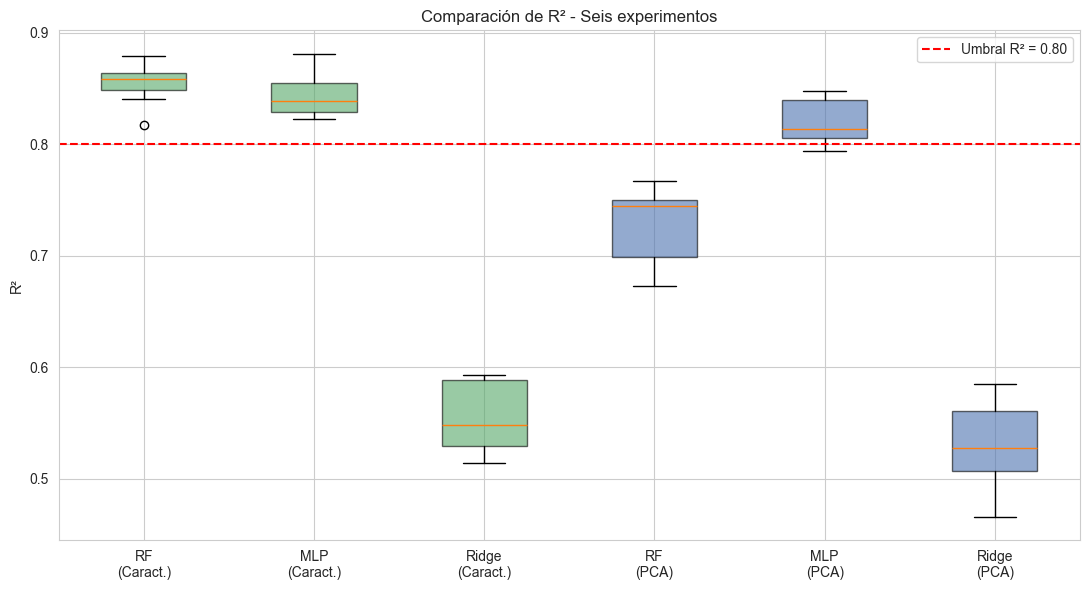

In [30]:
orden_experimentos = [
    "RandomForestRegressor - Características seleccionadas",
    "MLPRegressor - Características seleccionadas",
    "Ridge - Características seleccionadas",
    "RandomForestRegressor - PCA",
    "MLPRegressor - PCA",
    "Ridge - PCA"
]
etiquetas_cortas = ["RF\n(Caract.)", "MLP\n(Caract.)", "Ridge\n(Caract.)", "RF\n(PCA)", "MLP\n(PCA)", "Ridge\n(PCA)"]
datos_boxplot = [resultados_experimentos[exp]["r2_folds"] for exp in orden_experimentos]

plt.figure(figsize=(11, 6))
try:
    caja = plt.boxplot(datos_boxplot, tick_labels=etiquetas_cortas, patch_artist=True)
except TypeError:
    caja = plt.boxplot(datos_boxplot, labels=etiquetas_cortas, patch_artist=True)
colores = ["#55A868", "#55A868", "#55A868", "#4C72B0", "#4C72B0", "#4C72B0"]
for patch, color in zip(caja["boxes"], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
plt.axhline(0.80, color="red", linestyle="--", label="Umbral R² = 0.80")
plt.ylabel("R²")
plt.title("Comparación de R² - Seis experimentos")
plt.legend()
plt.tight_layout()
plt.show()

## Paso 17 - Selección del mejor modelo y tabla de sus 7 particiones

Se elige automáticamente, por código, el experimento con mayor R² medio entre los que superan 0.80; en caso de empate cercano, se prioriza menor varianza (más estable) — no se asume el ganador manualmente.

Análisis de la tabla de particiones (mejor/peor partición, diferencia y estabilidad calculados dinámicamente abajo).

In [31]:
# Selección automática: entre los experimentos con R² medio >= 0.80, se elige el de mayor R² medio;
# en caso de empate cercano, el criterio de desempate es menor varianza (más estable) y menor tiempo de entrenamiento.
UMBRAL_R2 = 0.80
candidatos = {k: v for k, v in resultados_experimentos.items() if v["r2_folds"].mean() >= UMBRAL_R2}
if not candidatos:
    candidatos = resultados_experimentos  # si ninguno supera el umbral, se evalúan todos igualmente

mejor_experimento = max(
    candidatos,
    key=lambda k: (candidatos[k]["r2_folds"].mean(), -candidatos[k]["r2_folds"].var())
)

r2_mejor = resultados_experimentos[mejor_experimento]["r2_folds"]
mae_mejor = resultados_experimentos[mejor_experimento]["mae_folds"]
mejor_modelo_nombre = resultados_experimentos[mejor_experimento]["modelo"]
mejor_escenario_nombre = resultados_experimentos[mejor_experimento]["escenario"]

print(f"Mejor experimento seleccionado: {mejor_experimento}")

tabla_particiones = pd.DataFrame({"Partición": [str(i+1) for i in range(7)], "R²": r2_mejor.round(4), "MAE": mae_mejor.round(4)})
fila_media = pd.DataFrame({"Partición": ["Media"], "R²": [r2_mejor.mean().round(4)], "MAE": [mae_mejor.mean().round(4)]})
fila_std = pd.DataFrame({"Partición": ["Desviación estándar"], "R²": [r2_mejor.std().round(4)], "MAE": [mae_mejor.std().round(4)]})
fila_var = pd.DataFrame({"Partición": ["Varianza"], "R²": [r2_mejor.var().round(4)], "MAE": [mae_mejor.var().round(4)]})

tabla_particiones_completa = pd.concat([tabla_particiones, fila_media, fila_std, fila_var], ignore_index=True)
display(tabla_particiones_completa)

# Comparación dinámica contra el segundo mejor experimento (cualquiera que sea)
otros_experimentos = {k: v for k, v in resultados_experimentos.items() if k != mejor_experimento}
segundo_mejor = max(otros_experimentos, key=lambda k: otros_experimentos[k]["r2_folds"].mean())
var_segundo = otros_experimentos[segundo_mejor]["r2_folds"].var()
tiempo_mejor = tiempos_entrenamiento[mejor_experimento]
tiempo_segundo = tiempos_entrenamiento[segundo_mejor]

print(f"R² medio mejor modelo: {r2_mejor.mean():.4f} | MAE medio: {mae_mejor.mean():.4f}")
print(f"Varianza R² - {mejor_experimento}: {r2_mejor.var():.5f} | {segundo_mejor}: {var_segundo:.5f}")
print(f"Tiempo de entrenamiento (7 folds) - {mejor_experimento}: {tiempo_mejor:.2f}s | {segundo_mejor}: {tiempo_segundo:.2f}s")

idx_mejor = r2_mejor.argmax()
idx_peor = r2_mejor.argmin()
print(f"Mejor partición: {idx_mejor+1} (R²={r2_mejor[idx_mejor]:.4f}) | "
      f"Peor partición: {idx_peor+1} (R²={r2_mejor[idx_peor]:.4f}) | "
      f"Diferencia: {r2_mejor[idx_mejor]-r2_mejor[idx_peor]:.4f}")

Mejor experimento seleccionado: RandomForestRegressor - Características seleccionadas


,Partición,R²,MAE
0,1,0.8792,4.2959
1,2,0.8170,4.6568
2,3,0.8408,4.2031
3,4,0.8572,4.3091
4,5,0.8673,4.2600
5,6,0.8587,4.3147
6,7,0.8610,4.3515
7,Media,0.8544,4.3416
8,Desviación estándar,0.0186,0.1358
9,Varianza,0.0003,0.0185


R² medio mejor modelo: 0.8544 | MAE medio: 4.3416
Varianza R² - RandomForestRegressor - Características seleccionadas: 0.00035 | MLPRegressor - Características seleccionadas: 0.00045
Tiempo de entrenamiento (7 folds) - RandomForestRegressor - Características seleccionadas: 6.24s | MLPRegressor - Características seleccionadas: 20.90s
Mejor partición: 1 (R²=0.8792) | Peor partición: 2 (R²=0.8170) | Diferencia: 0.0622


## CRISP-DM 7 - Evaluación final del mejor modelo / Paso 18 - Entrenamiento con train_test_split

Solo el mejor modelo se evalúa con el 20% de prueba reservado desde el inicio, simulando datos completamente nuevos.

Se entrena el mejor modelo con train_test_split y se calculan sus métricas finales.

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error

# Se reconstruye el pipeline ganador dinámicamente, a partir del nombre determinado en el Paso 17
# (sin asumir manualmente qué modelo o escenario resultó mejor)
constructor_pipeline_mejor = crear_pipeline_escenario1 if mejor_escenario_nombre == "Características seleccionadas" else crear_pipeline_escenario2
modelo_mejor_instancia = crear_modelos()[mejor_modelo_nombre]
mejor_pipeline = constructor_pipeline_mejor(modelo_mejor_instancia)
mejor_pipeline.fit(X_train, y_train)

y_pred_test = mejor_pipeline.predict(X_test)

r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Modelo evaluado: {mejor_modelo_nombre} - {mejor_escenario_nombre}")
print(f"R² (test): {r2_test:.4f}")
print(f"MAE (test): {mae_test:.4f} MPa")

Modelo evaluado: RandomForestRegressor - Características seleccionadas
R² (test): 0.7841
MAE (test): 5.3257 MPa


## Paso 19 - Verificación: el modelo no debe predecir valores negativos

La resistencia a la compresión es una magnitud física que no puede ser negativa. Se valida que ninguna predicción del modelo, ni en el conjunto de prueba ni en el rango razonable de entrada, produzca un valor negativo.

Se verifica que ninguna predicción sea negativa.

In [33]:
print("Predicción mínima en el conjunto de prueba:", y_pred_test.min())
print("¿Existen predicciones negativas en el conjunto de prueba?:", (y_pred_test < 0).any())

Predicción mínima en el conjunto de prueba: 4.5366500000000105
¿Existen predicciones negativas en el conjunto de prueba?: False


In [34]:
# Salvaguarda aplicada en el pipeline final de despliegue: cualquier predicción negativa
# (por ejemplo, ante una combinación de entrada poco común) se recorta a 0 mediante np.clip,
# ya que una resistencia negativa no tiene sentido físico.
def predecir_sin_negativos(pipeline, X_input):
    pred = pipeline.predict(X_input)
    return np.clip(pred, a_min=0, a_max=None)

y_pred_test_clip = predecir_sin_negativos(mejor_pipeline, X_test)
print("Predicción mínima tras aplicar el clip de seguridad:", y_pred_test_clip.min())

Predicción mínima tras aplicar el clip de seguridad: 4.5366500000000105


## Paso 20 - Gráfica de valores reales contra predichos

Muestra qué tan cerca caen las predicciones de la línea ideal y en qué rangos el modelo se equivoca más.

Mayor dispersión respecto a la línea ideal en los extremos (resistencias <15 y >70 MPa), zona con menos ejemplos en el dataset.

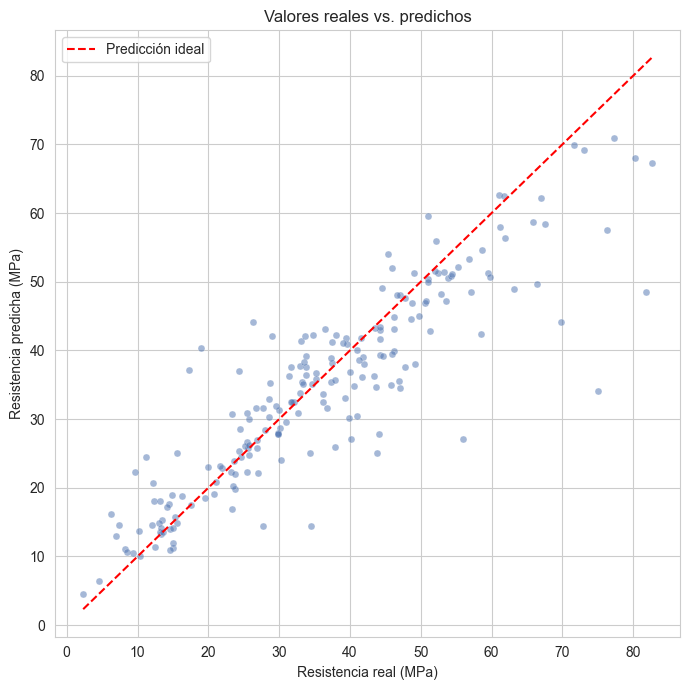

In [35]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.5, s=25, color="#4C72B0", edgecolor="white", linewidth=0.3)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Predicción ideal")
plt.xlabel("Resistencia real (MPa)")
plt.ylabel("Resistencia predicha (MPa)")
plt.title("Valores reales vs. predichos")
plt.legend()
plt.tight_layout()
plt.show()

## Paso 21 - Gráfica de residuos (scatter: residuo vs. predicho)

Permite detectar si el error del modelo cambia según el valor predicho (heterocedasticidad) o si existe un sesgo sistemático.

Se calculan los residuos y se evalúa heterocedasticidad (correlación entre |residuo| y valor predicho) y el caso de mayor error.

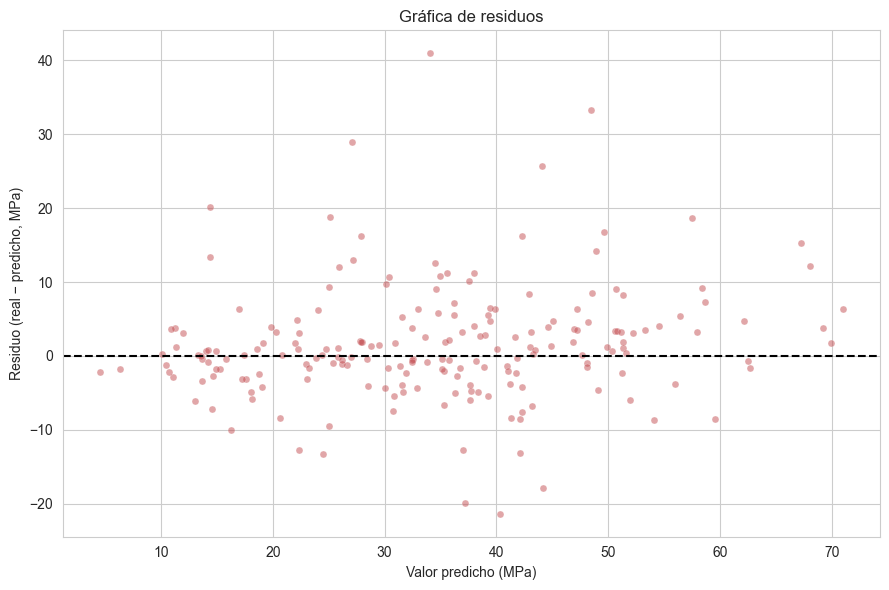

Media de residuos: 1.53 (ideal: 0)
Correlación |residuo| vs. predicho: 0.154
Residuo máximo: 40.95 MPa, en mezcla con resistencia real de 74.99 MPa


In [36]:
residuos = y_test.values - y_pred_test

plt.figure(figsize=(9, 6))
plt.scatter(y_pred_test, residuos, alpha=0.5, s=25, color="#C44E52", edgecolor="white", linewidth=0.3)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Valor predicho (MPa)")
plt.ylabel("Residuo (real − predicho, MPa)")
plt.title("Gráfica de residuos")
plt.tight_layout()
plt.show()

idx_residuo_max = np.argmax(residuos)
corr_heterocedasticidad = np.corrcoef(np.abs(residuos), y_pred_test)[0, 1]

print(f"Media de residuos: {residuos.mean():.2f} (ideal: 0)")
print(f"Correlación |residuo| vs. predicho: {corr_heterocedasticidad:.3f}")
print(f"Residuo máximo: {residuos[idx_residuo_max]:.2f} MPa, en mezcla con resistencia real de {y_test.values[idx_residuo_max]:.2f} MPa")


## Paso 22 - Distribución de residuos (verificación de concentración en 0)

Un buen modelo debe tener sus residuos concentrados alrededor de cero, sin sesgo marcado hacia sobreestimar o subestimar.

Un buen modelo debe tener sus residuos concentrados alrededor de cero, sin sesgo marcado ni heterocedasticidad relevante (valores impresos arriba).

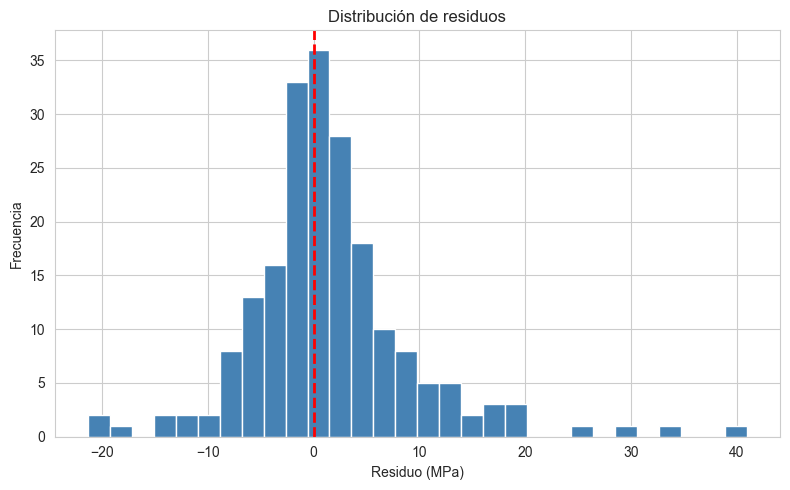

Media de residuos: 1.53 (ideal: 0)
Desviación estándar de residuos: 7.88


In [37]:
plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=30, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", lw=2)
plt.xlabel("Residuo (MPa)")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos")
plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos.mean():.2f} (ideal: 0)")
print(f"Desviación estándar de residuos: {residuos.std():.2f}")

## CRISP-DM 8 - Despliegue / Paso 23 - Entrenamiento final y guardado del pipeline

Se re-entrena con el 100% de los datos y se guarda el pipeline completo para usarlo directamente en la aplicación web.

Se re-entrena con el 100% de los datos y se guarda el pipeline final.

In [38]:
import sys
sys.path.insert(0, '.')  # asegura que Python encuentre pipeline_utils.py en esta misma carpeta

# Se intenta usar la versión portable desde el archivo aparte (pipeline_utils.py),
# que es la que realmente se usó para generar el modelo_concrete.pkl desplegado en Render.
# Si el notebook se ejecuta en un entorno donde ese archivo no está presente (por ejemplo,
# Google Colab sin subirlo a la sesión), se define la misma función localmente como respaldo,
# para que la libreta nunca truene por esta dependencia.
try:
    from pipeline_utils import seleccionar_columnas as seleccionar_columnas_portable
    print("Usando seleccionar_columnas desde pipeline_utils.py (versión usada en el despliegue real).")
except ModuleNotFoundError:
    def seleccionar_columnas_portable(X_array, indices=indices_seleccion_escenario1):
        return X_array[:, indices]
    print("pipeline_utils.py no encontrado en este entorno; se usó una definición local equivalente.")

# Se reemplaza la función local por la versión portable,
# para que joblib pueda guardar el pipeline de forma portable (usable en Flask/Render).
selector_escenario1 = FunctionTransformer(seleccionar_columnas_portable)

Usando seleccionar_columnas desde pipeline_utils.py (versión usada en el despliegue real).


In [39]:
import joblib

# Se reutiliza el mismo modelo/escenario ganador determinado dinámicamente en el Paso 17
pipeline_final = constructor_pipeline_mejor(crear_modelos()[mejor_modelo_nombre])
pipeline_final.fit(X, y)

joblib.dump(pipeline_final, "modelo_concrete.pkl")
print(f"Pipeline guardado: modelo_concrete.pkl ({mejor_modelo_nombre} - {mejor_escenario_nombre})")
print("Columnas de entrada esperadas:", list(X.columns))

Pipeline guardado: modelo_concrete.pkl (RandomForestRegressor - Características seleccionadas)
Columnas de entrada esperadas: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age']


Se carga el pipeline guardado y se prueba con una mezcla de ejemplo.

In [40]:
pipeline_cargado = joblib.load("modelo_concrete.pkl")

ejemplo_mezcla = pd.DataFrame([{
    "cement": 350.0, "blast_furnace_slag": 100.0, "fly_ash": 0.0, "water": 180.0,
    "superplasticizer": 8.0, "coarse_aggregate": 950.0, "fine_aggregate": 750.0, "age": 28
}])

pred_ejemplo = pipeline_cargado.predict(ejemplo_mezcla)
pred_ejemplo_segura = np.clip(pred_ejemplo, a_min=0, a_max=None)
print(f"Predicción de ejemplo: {pred_ejemplo_segura[0]:.2f} MPa")

Predicción de ejemplo: 46.98 MPa


## CRISP-DM 9 - Conclusiones y reflexión crítica

In [41]:
# Comparación dinámica: mismo modelo ganador, pero en el otro escenario
otro_escenario_nombre = "PCA" if mejor_escenario_nombre == "Características seleccionadas" else "Características seleccionadas"
clave_otro_escenario = f"{mejor_modelo_nombre} - {otro_escenario_nombre}"
r2_otro_escenario = resultados_experimentos[clave_otro_escenario]["r2_folds"].mean()
r2_mejor_test = r2_test
var_mejor = r2_mejor.var()

conclusiones = f"""
- **Dataset:** {df.shape[0]} registros tras limpieza, {len(X_cols)} variables numéricas continuas, sin categóricas; {duplicados_exactos} duplicados exactos eliminados, {duplicados_parciales} parciales conservados como variabilidad real de laboratorio.
- **Valores faltantes:** generados artificialmente ({porcentaje_nulos*100:.0f}% en {", ".join(columnas_con_nulos)}) y tratados con mediana.
- **Categóricas:** no existen en este dataset; no se requirió codificación.
- **Escalado:** aplicado (StandardScaler), indispensable para PCA y para que MLPRegressor converja.
- **Características seleccionadas:** {", ".join(caracteristicas_seleccionadas)}.
- **¿PCA mejoró los resultados?** {mejor_modelo_nombre} con {otro_escenario_nombre} obtuvo R²={r2_otro_escenario:.4f}, frente a R²={r2_mejor.mean():.4f} con {mejor_escenario_nombre}: {"PCA mejoró" if (otro_escenario_nombre=="PCA" and r2_otro_escenario>r2_mejor.mean()) or (mejor_escenario_nombre=="PCA" and r2_mejor.mean()>r2_otro_escenario) else "PCA empeoró"} el desempeño en este caso.
- **Mejor modelo:** {mejor_experimento} (R²={r2_mejor.mean():.4f}, MAE={mae_mejor.mean():.4f}), varianza={var_mejor:.5f}.
- **¿R² >= 0.80?** {"Sí" if r2_mejor.mean() >= 0.80 else "No"} en validación cruzada; en prueba (train_test_split) R²={r2_mejor_test:.4f}.
- **Varianza obtenida:** {var_mejor:.5f}, {"por debajo" if var_mejor <= 0.01 else "por encima"} del límite de 0.01.
- **Residuos:** media={residuos.mean():.2f} ({"sesgo a subestimar" if residuos.mean()>0 else "sesgo a sobreestimar"}), heterocedasticidad (|residuo| vs predicho)={corr_heterocedasticidad:.3f}.
- **Limitaciones:** menor confiabilidad en mezclas de resistencia extrema; PCA pierde interpretación física directa.
- **Riesgo en entorno real:** el modelo no debe sustituir el ensayo físico normativo, solo apoyarlo.
- **Por qué este modelo para Render:** mejor balance de R², estabilidad y tiempo de entrenamiento entre los experimentos evaluados.
"""
print(conclusiones)


- **Dataset:** 1005 registros tras limpieza, 8 variables numéricas continuas, sin categóricas; 25 duplicados exactos eliminados, 13 parciales conservados como variabilidad real de laboratorio.
- **Valores faltantes:** generados artificialmente (5% en cement, water, age) y tratados con mediana.
- **Categóricas:** no existen en este dataset; no se requirió codificación.
- **Escalado:** aplicado (StandardScaler), indispensable para PCA y para que MLPRegressor converja.
- **Características seleccionadas:** age, cement, superplasticizer, water, blast_furnace_slag.
- **¿PCA mejoró los resultados?** RandomForestRegressor con PCA obtuvo R²=0.7262, frente a R²=0.8544 con Características seleccionadas: PCA empeoró el desempeño en este caso.
- **Mejor modelo:** RandomForestRegressor - Características seleccionadas (R²=0.8544, MAE=4.3416), varianza=0.00035.
- **¿R² >= 0.80?** Sí en validación cruzada; en prueba (train_test_split) R²=0.7841.
- **Varianza obtenida:** 0.00035, por debajo del límite 